# 미분의 정의에 대한 디스커션 (뉴진수 5강)-09강 3기 05강

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

x, y, h, t = sp.symbols("x y h t", real=True)

## 1. 방향도함수로 미분을 흉내 내 본 첫 시도
단위벡터 $D$ 를 고정하고 $\displaystyle\lim_{h\to0}\frac{f(P+hD)-f(P)}{h}$ 를 봅니다.
$P,D$ 가 고정되어 있으므로 이것은 사실상 $h$ 에 대한 일변수 함수의 미분입니다.
매끄러운 함수 $f(x,y)=x^2+xy+y^2$ 의 원점에서, 방향도함수가 표준 공식
$\nabla f(P)\cdot D$ 와 일치하는지 직접 확인합니다.

In [2]:
f_smooth = x**2 + x*y + y**2
P = (sp.Integer(0), sp.Integer(0))
# 임의 단위벡터 D = (cosθ, sinθ)
th = sp.symbols("theta", real=True)
D = (sp.cos(th), sp.sin(th))

g = f_smooth.subs({x: P[0] + h*D[0], y: P[1] + h*D[1]})          # f(P+hD), h의 일변수 함수
ddir = sp.limit((g - f_smooth.subs({x: P[0], y: P[1]})) / h, h, 0)
grad = [sp.diff(f_smooth, v).subs({x: P[0], y: P[1]}) for v in (x, y)]
print("f(x,y) = x^2 + x y + y^2,   P = (0,0)")
print("directional-deriv limit  =", sp.simplify(ddir))
print("grad f(P) . D             =", sp.simplify(grad[0]*D[0] + grad[1]*D[1]))
print("=> they agree for every direction theta")

f(x,y) = x^2 + x y + y^2,   P = (0,0)
directional-deriv limit  = 0
grad f(P) . D             = 0
=> they agree for every direction theta


## 2. 낭떠러지(크레바스) 함수 — 직선으로는 안 떨어진다
노트가 그린 "좁은 틈만 값이 다른 불연속 함수"를 그대로 구현합니다.
$$f(x,y)=\begin{cases}1 & 0<y<x^2\\[2pt]0 & \text{그 밖}\end{cases}$$
원점 위에 얹힌 포물선 모양의 **좁은 크레바스**($0<y<x^2$)에서만 값이 $1$ 입니다.
- **직선 경로** $hD$ 로 들어오면, $h$ 를 줄이는 순간 직선은 곧 틈 $0<y<x^2$ 을
  비껴 바닥($f\equiv0$)으로 들어옵니다 → $f(P+hD)-f(P)=0$ → 모든 방향도함수가 $0$.
- 그러나 **틈을 따라 휘어 들어오는 곡선** $y=\tfrac12 x^2$ 위에서는 $f\equiv1$ →
  원점에서 **불연속**. "직선마다 멀쩡한데 함수는 불연속"인 모순.

In [3]:
def fcre(X, Y):
    return 1.0 if (Y > 0 and Y < X**2) else 0.0           # 좁은 틈 0<y<x^2 에서만 1

# (a) 임의의 고정 방향 D=(a,b) 직선 위에서: h 가 충분히 작으면 f=0
print("along a fixed line (x,y)=h(a,b), as h->0:")
for (a, b) in [(1, 0), (0, 1), (1, 1), (-1, 2), (0.6, 0.8)]:
    small = [fcre(h0 * a, h0 * b) for h0 in [1e-2, 1e-3, 1e-4, 1e-5]]
    print(f"   D=({a:>4},{b:>4}):  f(hD) for shrinking h = {small}  -> directional deriv = 0")

# (b) 틈을 따라가는 곡선 y = x^2 / 2 위에서: f === 1
print("\nalong the curve  y = x^2 / 2  (inside the gap):")
print("   f(x, x^2/2) =", [fcre(x0, 0.5 * x0**2) for x0 in [0.1, 0.01, 0.001]],
      "  -> f -> 1, but f(0,0)=0  => discontinuous")

along a fixed line (x,y)=h(a,b), as h->0:
   D=(   1,   0):  f(hD) for shrinking h = [0.0, 0.0, 0.0, 0.0]  -> directional deriv = 0
   D=(   0,   1):  f(hD) for shrinking h = [0.0, 0.0, 0.0, 0.0]  -> directional deriv = 0
   D=(   1,   1):  f(hD) for shrinking h = [0.0, 0.0, 0.0, 0.0]  -> directional deriv = 0
   D=(  -1,   2):  f(hD) for shrinking h = [0.0, 0.0, 0.0, 0.0]  -> directional deriv = 0
   D=( 0.6, 0.8):  f(hD) for shrinking h = [0.0, 0.0, 0.0, 0.0]  -> directional deriv = 0

along the curve  y = x^2 / 2  (inside the gap):
   f(x, x^2/2) = [1.0, 1.0, 1.0]   -> f -> 1, but f(0,0)=0  => discontinuous


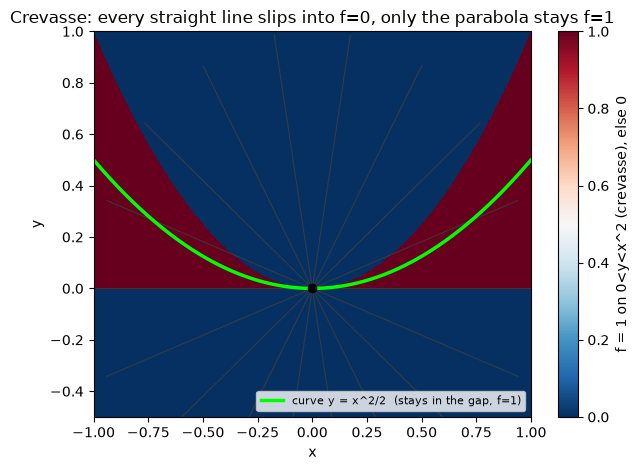

In [4]:
xs = np.linspace(-1.0, 1.0, 600)
ys = np.linspace(-0.5, 1.0, 450)
X, Y = np.meshgrid(xs, ys)
Z = np.where((Y > 0) & (Y < X**2), 1.0, 0.0)

fig, ax = plt.subplots(figsize=(6.4, 4.8))
pc = ax.pcolormesh(X, Y, Z, shading="auto", cmap="RdBu_r", vmin=0, vmax=1)
fig.colorbar(pc, ax=ax, label="f = 1 on 0<y<x^2 (crevasse), else 0")
# 원점을 지나는 직선들 (방향 고정) - 작은 h 에서 모두 바닥(0)을 지난다
for ang in np.linspace(0, np.pi, 9, endpoint=False):
    dx, dy = np.cos(ang), np.sin(ang)
    ax.plot([-dx, dx], [-dy, dy], color="0.25", lw=0.8, alpha=0.75)
# 틈으로 파고드는 곡선 y = x^2/2  (계속 f=1)
ax.plot(xs, 0.5 * xs**2, color="lime", lw=2.5, label="curve y = x^2/2  (stays in the gap, f=1)")
ax.plot(0, 0, "ko", ms=6)
ax.set_xlim(-1, 1); ax.set_ylim(-0.5, 1.0)
ax.set_title("Crevasse: every straight line slips into f=0, only the parabola stays f=1")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
plt.show()

## 4. 그레디언트를 어떻게 만들 것인가 — 내적의 역할
매끄러운 함수에서는 그레디언트 벡터 $\nabla f(P)$ **하나**만 있으면 임의 방향 $D$(단위벡터)와의
**내적** $\langle\nabla f(P),D\rangle$ 로 그 방향의 변화율을 전부 출력할 수 있습니다.
또 방향도함수는 $D$ 가 $\nabla f$ 와 같은 방향일 때 최대(=$\|\nabla f\|$)가 됩니다.

In [5]:
fn = x**2 + x*y + y**2
P2 = (sp.Rational(1, 2), sp.Rational(1, 1))
gP = sp.Matrix([sp.diff(fn, x), sp.diff(fn, y)]).subs({x: P2[0], y: P2[1]})
print("grad f(P) =", gP.T.tolist()[0], "  at P =", (float(P2[0]), float(P2[1])))

gv = np.array([float(gP[0]), float(gP[1])])
thetas = np.linspace(0, 2*np.pi, 361)
Dirs = np.stack([np.cos(thetas), np.sin(thetas)])      # unit directions
ddirs = gv @ Dirs                                      # directional derivative = grad . D
imax = int(np.argmax(ddirs))
print("max directional derivative =", round(ddirs[imax], 4),
      " at theta =", round(np.degrees(thetas[imax]), 1), "deg")
print("||grad f(P)||              =", round(np.linalg.norm(gv), 4), " (matches the max)")
print("angle of grad f(P)         =", round(np.degrees(np.arctan2(gv[1], gv[0])), 1), "deg")

grad f(P) = [2, 5/2]   at P = (0.5, 1.0)
max directional derivative = 3.2015  at theta = 51.0 deg
||grad f(P)||              = 3.2016  (matches the max)
angle of grad f(P)         = 51.3 deg


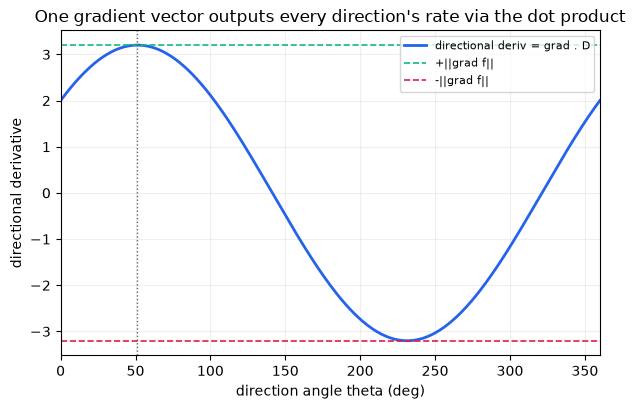

In [6]:
fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.plot(np.degrees(thetas), ddirs, color="#2563eb", lw=2, label="directional deriv = grad . D")
ax.axhline(np.linalg.norm(gv), color="#10b981", ls="--", lw=1.2, label="+||grad f||")
ax.axhline(-np.linalg.norm(gv), color="#e11d48", ls="--", lw=1.2, label="-||grad f||")
ax.axvline(np.degrees(thetas[imax]), color="0.4", ls=":", lw=1)
ax.set_xlabel("direction angle theta (deg)")
ax.set_ylabel("directional derivative")
ax.set_title("One gradient vector outputs every direction's rate via the dot product")
ax.set_xlim(0, 360); ax.legend(fontsize=8); ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

## 7. 1차 근사로 다시 읽기 — 분자가 더 빨리 0으로 가야 한다
미분가능의 정의식
$$\lim_{K\to0}\frac{\bigl|f(P+K)-f(P)-\langle\nabla f(P),K\rangle\bigr|}{|K|}=0$$
은 곧 "1차 근사 $f(P)+\langle\nabla f(P),K\rangle$ 의 **오차가 $|K|$ 보다 빨리 0으로 간다**"는 뜻입니다.
- **매끄러운 함수**: 비율이 $|K|\to0$ 에서 0 으로 → 미분가능.
- **크레바스 함수**: 방향도함수가 모두 0 이라 $\nabla f(0,0)=(0,0)$ 으로 둘 수밖에 없는데,
  그래도 비율이 0 으로 가지 않음 → 미분 불가능.

In [7]:
# (a) 매끄러운 함수: 오차/|K| 가 0으로 가는지 수치 확인
fn_l = sp.lambdify((x, y), fn, "numpy")
gx = sp.lambdify((x, y), sp.diff(fn, x), "numpy")
gy = sp.lambdify((x, y), sp.diff(fn, y), "numpy")
px, py = 0.5, 1.0
g0 = np.array([gx(px, py), gy(px, py)])
print("smooth f = x^2 + xy + y^2  at P=(0.5,1.0),  grad =", g0)
print(f"{'|K|':>10}{'error/|K|':>14}")
for eps in [0.4, 0.2, 0.1, 0.05, 0.02, 0.01]:
    ratios = []
    for ang in np.linspace(0, 2*np.pi, 64, endpoint=False):
        K = eps * np.array([np.cos(ang), np.sin(ang)])
        err = abs(fn_l(px + K[0], py + K[1]) - fn_l(px, py) - g0 @ K)
        ratios.append(err / np.linalg.norm(K))
    print(f"{eps:>10.3f}{max(ratios):>14.5f}")

smooth f = x^2 + xy + y^2  at P=(0.5,1.0),  grad = [2.  2.5]
       |K|     error/|K|
     0.400       0.60000
     0.200       0.30000
     0.100       0.15000
     0.050       0.07500
     0.020       0.03000
     0.010       0.01500


In [8]:
# (b) 크레바스 함수: grad=(0,0) 으로 두어도 디스크 위 error/|K| 가 0으로 안 간다.
# 반지름 eps 원에는 틈(0<y<x^2)에 들어가는 점이 늘 있어 거기서 f=1 → error/|K| = 1/eps 로 발산.
print("crevasse f (indicator of 0<y<x^2) at P=(0,0), grad assumed (0,0):")
print(f"{'|K|':>10}{'max error/|K|':>16}")
worst = []
for eps in [0.4, 0.2, 0.1, 0.05, 0.02, 0.01]:
    ratios = []
    for ang in np.linspace(0, 2*np.pi, 4000, endpoint=False):
        K = eps * np.array([np.cos(ang), np.sin(ang)])
        err = abs(fcre(K[0], K[1]) - 0.0 - 0.0)          # f(P)=0, <grad,K>=0
        ratios.append(err / np.linalg.norm(K))
    worst.append((eps, max(ratios)))
    print(f"{eps:>10.3f}{max(ratios):>16.5f}")

crevasse f (indicator of 0<y<x^2) at P=(0,0), grad assumed (0,0):
       |K|   max error/|K|
     0.400         2.50000
     0.200         5.00000
     0.100        10.00000
     0.050        20.00000
     0.020        50.00000
     0.010       100.00000


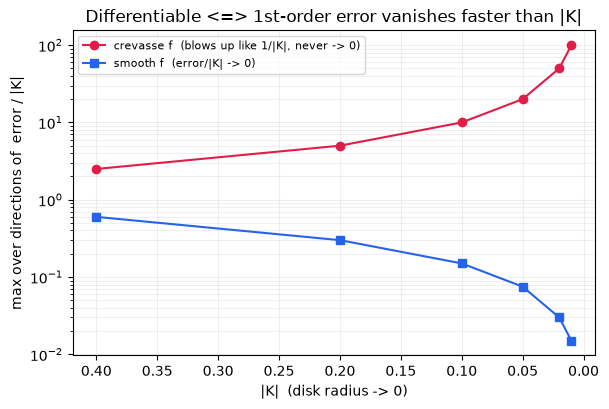

In [9]:
fig, ax = plt.subplots(figsize=(6.2, 4.2))
eps_grid = np.array([w[0] for w in worst])
smooth_max = []
for eps in eps_grid:
    rr = []
    for ang in np.linspace(0, 2*np.pi, 720, endpoint=False):
        K = eps * np.array([np.cos(ang), np.sin(ang)])
        err = abs(fn_l(px + K[0], py + K[1]) - fn_l(px, py) - g0 @ K)
        rr.append(err / np.linalg.norm(K))
    smooth_max.append(max(rr))
ax.plot(eps_grid, [w[1] for w in worst], "o-", color="#e11d48",
        label="crevasse f  (blows up like 1/|K|, never -> 0)")
ax.plot(eps_grid, smooth_max, "s-", color="#2563eb",
        label="smooth f  (error/|K| -> 0)")
ax.set_xlabel("|K|  (disk radius -> 0)")
ax.set_ylabel("max over directions of  error / |K|")
ax.set_title("Differentiable <=> 1st-order error vanishes faster than |K|")
ax.set_yscale("log")
ax.invert_xaxis()
ax.legend(fontsize=8); ax.grid(alpha=0.2, which="both")
fig.tight_layout()
plt.show()